# Homework 2

这次作业包括canny边缘检测算法的实现

In [ ]:
# Setup
import numpy as np

import matplotlib.pyplot as plt
from skimage import io

%matplotlib inline
plt.rcParams['figure.figsize'] = (15.0, 12.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading extenrnal modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Canny边缘检测算法

## 算法原理
Canny边缘检测是由John F. Canny在1986年开发的多级边缘检测算法，被认为是边缘检测的最优算法。

### 主要步骤：
1. **高斯滤波**：使用高斯滤波器平滑图像，消除噪声
2. **计算梯度**：使用Sobel算子计算梯度的幅值和方向
3. **非极大值抑制**：细化边缘，只保留局部梯度最大的点
4. **双阈值检测**：通过高低阈值确定真实和潜在的边缘
5. **边缘连接**：抑制孤立的弱边缘，完成边缘连接

### 1.1 高斯滤波

高斯滤波是一种线性平滑滤波，适用于消除高斯噪声。它通过对图像进行加权平均处理，每个像素点的值都由其本身和邻域内的其他像素值经过加权平均后得到。

$(2k+1)\times(2k+1)$ 的高斯核公式如下：

$$h_{ij}=\frac{1}{2\pi\sigma^2}\exp{\Bigl(-\frac{(i-k)^2+(j-k)^2}{2\sigma^2}\Bigr)}, 0\leq i,j < 2k+1$$

请实现`gaussian_kernel`，

In [ ]:
def gaussian_kernel(size, sigma):
    """ Implementation of Gaussian Kernel.

    This function follows the gaussian kernel formula,
    and creates a kernel matrix.

    Hints:
    - Use np.pi and np.exp to compute pi and exp.

    Args:
        size: int of the size of output matrix.
        sigma: float of sigma to calculate kernel.

    Returns:
        kernel: numpy array of shape (size, size).
    """

    kernel = np.zeros((size, size))

    ### YOUR CODE HERE

    ### END YOUR CODE

    return kernel

In [112]:
# Define 3x3 Gaussian kernel with std = 1
kernel = gaussian_kernel(3, 1)
kernel_test = np.array(
    [[ 0.05854983, 0.09653235, 0.05854983],
     [ 0.09653235, 0.15915494, 0.09653235],
     [ 0.05854983, 0.09653235, 0.05854983]]
)

# Test Gaussian kernel
if not np.allclose(kernel, kernel_test):
    print('Incorrect values! Please check your implementation.')

### 什么是卷积？
卷积是两个函数之间的一种数学运算，在图像处理中，我们用卷积核（kernel）对图像进行滤波操作。

### 离散二维卷积公式

对于图像 $f$ 和卷积核 $h$，卷积操作定义为：

$$(f * h)(x,y) = \sum_{i=-a}^{a}\sum_{j=-b}^{b} f(x-i, y-j) \cdot h(i,j)$$

其中，卷积核的大小为 $(2a+1) \times (2b+1)$。

### 卷积的物理意义
- **平滑/模糊**：用邻域像素的平均值代替当前像素
- **锐化**：突出像素与邻域的差异
- **边缘检测**：检测像素值的变化率
- **特征提取**：提取特定的图像特征


In [ ]:
from scipy.signal import convolve2d

def conv(image, kernel):
    """ An implementation of convolution filter.

    This function uses element-wise multiplication and np.sum()
    to efficiently compute weighted sum of neighborhood at each
    pixel.

    Args:
        image: numpy array of shape (Hi, Wi).
        kernel: numpy array of shape (Hk, Wk).

    Returns:
        out: numpy array of shape (Hi, Wi).
    """
    Hi, Wi = image.shape
    Hk, Wk = kernel.shape
    out = np.zeros((Hi, Wi))

    # For this assignment, we will use edge values to pad the images.
    # Zero padding will make derivatives at the image boundary very big,
    # whereas we want to ignore the edges at the boundary.
    pad_width0 = Hk // 2
    pad_width1 = Wk // 2
    pad_width = ((pad_width0,pad_width0),(pad_width1,pad_width1))
    padded = np.pad(image, pad_width, mode='edge')

    out = convolve2d(padded, kernel, mode='valid')


    return out

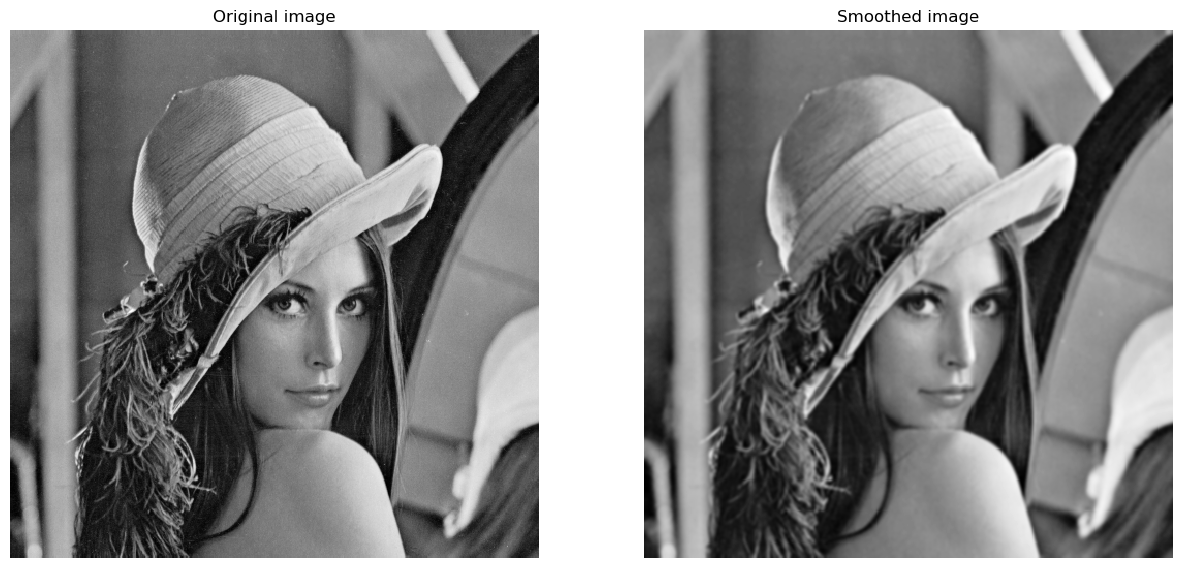

In [114]:
# Test with different kernel_size and sigma
kernel_size = 5
sigma = 1.4

# Load image
img = io.imread('lena.png', as_gray=True)

# Define 5x5 Gaussian kernel with std = sigma
kernel = gaussian_kernel(kernel_size, sigma)

# Convolve image with kernel to achieve smoothed effect
smoothed = conv(img, kernel)


plt.subplot(1,2,1)
plt.imshow(img)
plt.title('Original image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(smoothed)
plt.title('Smoothed image')
plt.axis('off')

plt.show()

### 1.2 计算梯度

二维标量函数 $I:\mathbb{R}^2\rightarrow{\mathbb{R}}$ 在笛卡尔坐标系中的梯度定义为：

$$\nabla{I(x,y)}=\bigl[\frac{\partial{I}}{\partial{x}},\frac{\partial{I}}{\partial{y}}\bigr],$$

其中

$$
\frac{\partial{I(x,y)}}{\partial{x}}=\lim_{\Delta{x}\to{0}}\frac{I(x+\Delta{x},y)-I(x,y)}{\Delta{x}} \\
\frac{\partial{I(x,y)}}{\partial{y}}=\lim_{\Delta{y}\to{0}}\frac{I(x,y+\Delta{y})-I(x,y)}{\Delta{y}}.
$$

对于图像，我们可以通过计算相邻像素的差值来近似偏导数：

$$
\frac{\partial{I(x,y)}}{\partial{x}}\approx{\frac{I(x+1,y)-I(x-1,y)}{2}} \\
\frac{\partial{I(x,y)}}{\partial{y}}\approx{\frac{I(x,y+1)-I(x,y-1)}{2}}
$$

注意，偏导数可以通过将图像 $I$ 与适当的卷积核 $D_x$ 和 $D_y$ 进行卷积来计算：

$$
\frac{\partial{I}}{\partial{x}}\approx{I*D_x}=G_x \\
\frac{\partial{I}}{\partial{y}}\approx{I*D_y}=G_y
$$


#### 任务小结
找到卷积核 $D_x$ 和 $D_y$，并使用 `conv` 函数以及中心差分核[0.5, 0, -0.5]实现 **`partial_x`** 和 **`partial_y`**。

*提示：记住卷积操作会翻转卷积核。*


现在，我们可以使用两个偏导数来计算梯度的幅值和方向：

$$
G = \sqrt{G_{x}^{2}+G_{y}^{2}} \\
\Theta = arctan\bigl(\frac{G_{y}}{G_{x}}\bigr)
$$

实现 **`gradient`** 函数，该函数接收图像并输出 $G$ 和 $\Theta$。

In [ ]:
def partial_x(img):
    """ Computes partial x-derivative of input img.

    Hints:
        - You may use the conv function in defined in this file.

    Args:
        img: numpy array of shape (H, W).
    Returns:
        out: x-derivative image.
    """

    out = None

    ### YOUR CODE HERE

    ### END YOUR CODE

    return out

def partial_y(img):
    """ Computes partial y-derivative of input img.

    Hints:
        - You may use the conv function in defined in this file.

    Args:
        img: numpy array of shape (H, W).
    Returns:
        out: y-derivative image.
    """

    out = None

    ### YOUR CODE HERE

    ### END YOUR CODE

    return out


def gradient(img):
    """ Returns gradient magnitude and direction of input img.

    Args:
        img: Grayscale image. Numpy array of shape (H, W).

    Returns:
        G: Magnitude of gradient at each pixel in img.
            Numpy array of shape (H, W).
        theta: Direction(in degrees, 0 <= theta < 360) of gradient
            at each pixel in img. Numpy array of shape (H, W).

    Hints:
        - Use np.sqrt and np.arctan2 to calculate square root and arctan
    """
    G = np.zeros(img.shape)
    theta = np.zeros(img.shape)

    ### YOUR CODE HERE

    ### END YOUR CODE

    return G, theta

In [129]:
# Test input
I = np.array(
    [[0, 0, 0],
     [0, 1, 0],
     [0, 0, 0]]
)

# Expected outputs
I_x_test = np.array(
    [[ 0, 0, 0],
     [ 0.5, 0, -0.5],
     [ 0, 0, 0]]
)

I_y_test = np.array(
    [[ 0, 0.5, 0],
     [ 0, 0, 0],
     [ 0, -0.5, 0]]
)

# Compute partial derivatives
I_x = partial_x(I)
I_y = partial_y(I)

# Test correctness of partial_x and partial_y
if not np.all(I_x == I_x_test):
    print('partial_x incorrect')
    
if not np.all(I_y == I_y_test):
    print('partial_y incorrect')

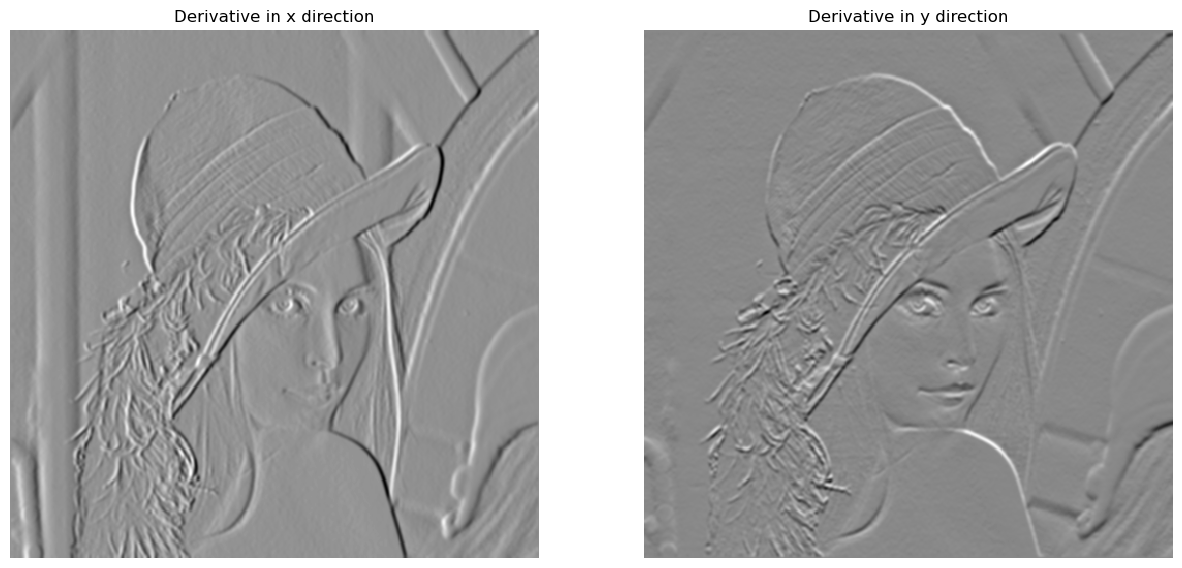

In [117]:
# Compute partial derivatives of smoothed image
Gx = partial_x(smoothed)
Gy = partial_y(smoothed)

plt.subplot(1,2,1)
plt.imshow(Gx)
plt.title('Derivative in x direction')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(Gy)
plt.title('Derivative in y direction')
plt.axis('off')

plt.show()

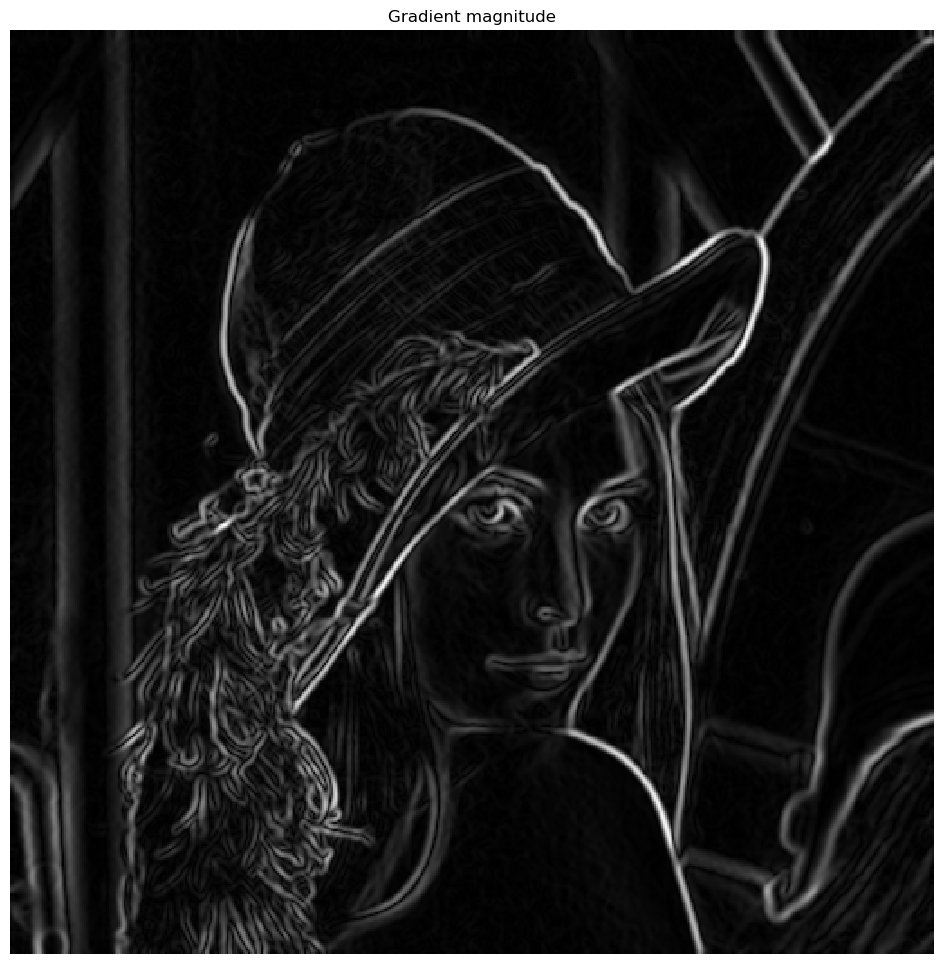

In [118]:
G, theta = gradient(smoothed)

if not np.all(G >= 0):
    print('Magnitude of gradients should be non-negative.')
    
if not np.all((theta >= 0) * (theta < 360)):
    print('Direction of gradients should be in range 0 <= theta < 360')

plt.imshow(G)
plt.title('Gradient magnitude')
plt.axis('off')
plt.show()

### 1.3 非极大值抑制


### 什么是非极大值抑制？
非极大值抑制是Canny边缘检测中的关键步骤，用于细化边缘。它通过检查像素点在其梯度方向上是局部最大值，来抑制非边缘像素。

### 为什么要进行非极大值抑制？
在梯度计算后，得到的边缘往往比较粗（多个像素宽）。非极大值抑制可以：
- **细化边缘**：将宽边缘缩减为单像素宽度
- **去除伪边缘**：抑制非最大值的梯度响应
- **精确定位**：使边缘位置更加精确

### 算法原理

**核心思想**：只有梯度幅值的局部极大值点才被保留为边缘点。

**具体步骤**：

1. **梯度方向量化**：将梯度方向（0-180°）量化为4个主要方向
   - 水平方向（0°）
   - 45°方向（45°）  
   - 垂直方向（90°）
   - 135°方向（135°）

2. **邻域比较**：在每个像素点，沿着梯度方向比较其与相邻两个像素的幅值

3. **抑制非极大值**：如果当前像素不是最大值，则将其抑制（设为0）

### 梯度方向量化规则

| 梯度角度范围 | 量化方向 | 比较的邻域像素 |
|-------------|---------|---------------|
| 0° ± 22.5° | 水平(0°) | 左右两侧像素 |
| 45° ± 22.5° | 对角线(45°) | 右上和左下像素 |
| 90° ± 22.5° | 垂直(90°) | 上下两侧像素 |
| 135° ± 22.5° | 对角线(135°) | 左上和右下像素 |

### 数学表达

对于像素点 $(x,y)$，梯度幅值为 $M(x,y)$，梯度方向为 $\theta(x,y)$：

如果 $M(x,y)$ 大于沿着梯度方向的两个相邻像素的幅值，则保留；否则置0。

### 任务小结

你应该能够看到，从平滑图像的梯度中提取出的边缘相当厚且模糊。此步骤的目的是将"模糊"的边缘转换为"锐利"的边缘。基本上，这是通过保留梯度图像中的所有局部极大值并丢弃其他所有值来实现的。该算法针对梯度图像中的每个像素 $(x,y)$ 执行以下操作：

1. 将梯度方向 $\Theta[y,x]$ 四舍五入到最近的 45 度方向，对应使用 8 连通邻域。

2. 将当前像素的边缘强度与正负梯度方向上的像素边缘强度进行比较。例如，如果梯度方向是南向（theta=90），则与北向和南向的像素进行比较。

3. 如果当前像素的边缘强度最大，则保留该边缘强度值；如果不是，则抑制（即移除）该值。

实现 non_maximum_suppression 函数。

如果在差异图像中看到白色斑点，则应检查你的实现。

In [ ]:
def non_maximum_suppression(G, theta):
    """ Performs non-maximum suppression.

    This function performs non-maximum suppression along the direction
    of gradient (theta) on the gradient magnitude image (G).

    Args:
        G: gradient magnitude image with shape of (H, W).
        theta: direction of gradients with shape of (H, W).

    Returns:
        out: non-maxima suppressed image.
    """
    H, W = G.shape
    out = np.zeros((H, W))

    # Round the gradient direction to the nearest 45 degrees
    theta = np.floor((theta + 22.5) / 45) * 45

    ### BEGIN YOUR CODE

    ### END YOUR CODE

    return out

In [120]:
# Test input
g = np.array(
    [[0.4, 0.5, 0.6],
     [0.3, 0.5, 0.7],
     [0.4, 0.5, 0.6]]
)

# Print out non-maximum suppressed output
# varying theta
for angle in range(0, 180, 45):
    print('Thetas:', angle)
    t = np.ones((3, 3)) * angle # Initialize theta
    print(non_maximum_suppression(g, t))

Thetas: 0
[[0.  0.  0.6]
 [0.  0.  0.7]
 [0.  0.  0.6]]
Thetas: 45
[[0.  0.  0.6]
 [0.  0.  0.7]
 [0.4 0.5 0.6]]
Thetas: 90
[[0.4 0.5 0. ]
 [0.  0.5 0.7]
 [0.4 0.5 0. ]]
Thetas: 135
[[0.4 0.5 0.6]
 [0.  0.  0.7]
 [0.  0.  0.6]]


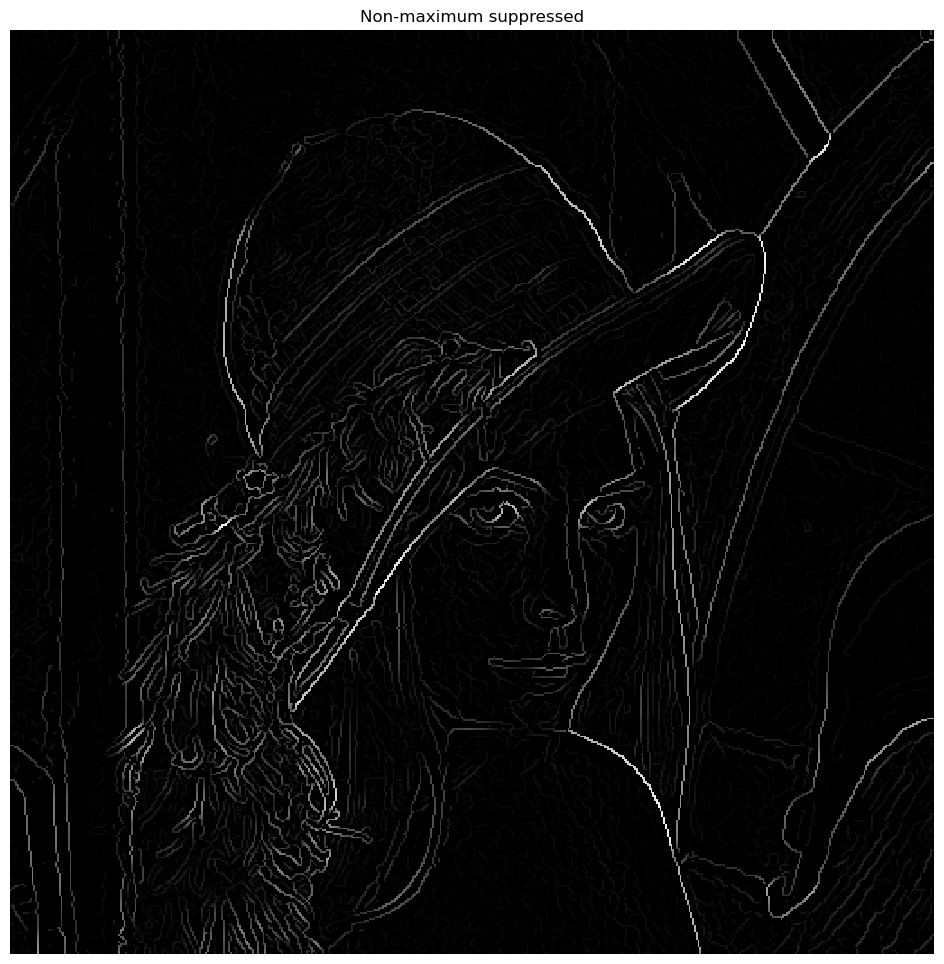

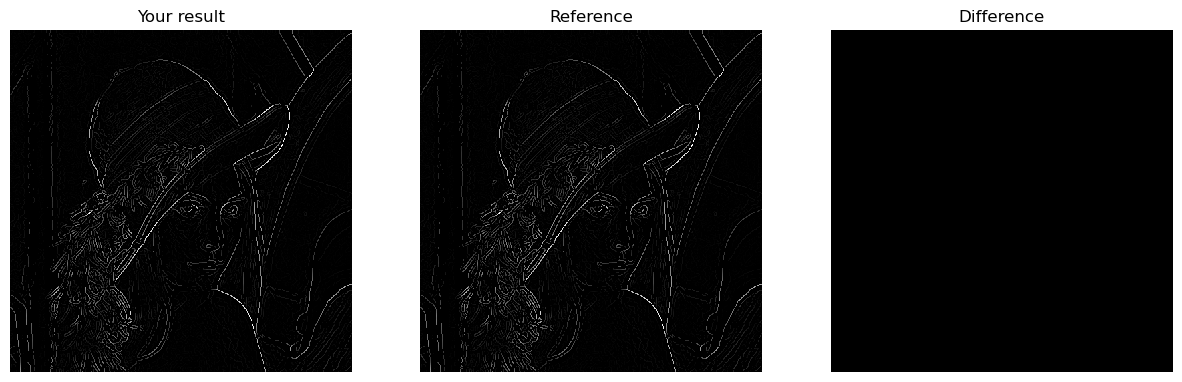

In [121]:
nms = non_maximum_suppression(G, theta)
plt.imshow(nms)
plt.title('Non-maximum suppressed')
plt.axis('off')
plt.show()


plt.subplot(1, 3, 1)
plt.imshow(nms)
plt.axis('off')
plt.title('Your result')

plt.subplot(1, 3, 2)
reference = np.load('references/lena_non_max_suppressed.npy')
plt.imshow(reference)
plt.axis('off')
plt.title('Reference')

plt.subplot(1, 3, 3)
plt.imshow(nms - reference)
plt.title('Difference')
plt.axis('off')
plt.show()

### 1.4 双阈值检测 Double Thresholding 

### 什么是双阈值检测？
双阈值检测是Canny边缘检测中的关键步骤，用于区分强边缘、弱边缘和非边缘。它通过设置高低两个阈值，将像素分为三类：

- **强边缘**：梯度幅值 > 高阈值
- **弱边缘**：低阈值 ≤ 梯度幅值 ≤ 高阈值
- **非边缘**：梯度幅值 < 低阈值

### 为什么要使用双阈值？
单阈值检测存在以下问题：
- **阈值过高**：丢失真实边缘
- **阈值过低**：保留过多噪声
- **无法区分**：无法区分强边缘和弱边缘

双阈值的优势：
- **保留强边缘**：确保主要边缘的完整性
- **保留弱边缘**：保留可能真实的弱边缘
- **抑制噪声**：通过阈值滤除明显噪声

### 数学表示

对于像素点 $(x,y)$，梯度幅值为 $M(x,y)$：

$$
\text{EdgeType}(x,y) = 
\begin{cases}
\text{强边缘}, & \text{if } M(x,y) > T_{\text{high}} \\
\text{弱边缘}, & \text{if } T_{\text{low}} \leq M(x,y) \leq T_{\text{high}} \\
\text{非边缘}, & \text{if } M(x,y) < T_{\text{low}}
\end{cases}
$$

其中：
- $T_{\text{high}}$ 是高阈值
- $T_{\text{low}}$ 是低阈值

### 阈值选取原则

**经验法则**：
- 高阈值 : 低阈值 ≈ 2 : 1 到 3 : 1
- 高阈值通常设置为梯度直方图的某个百分位数
- 低阈值用于保留边缘的连续性

请实现 **`double_thresholding`** 

In [ ]:
def double_thresholding(img, high, low):
    """
    Args:
        img: numpy array of shape (H, W) representing NMS edge response.
        high: high threshold(float) for strong edges.
        low: low threshold(float) for weak edges.

    Returns:
        strong_edges: Boolean array representing strong edges.
            Strong edeges are the pixels with the values greater than
            the higher threshold.
        weak_edges: Boolean array representing weak edges.
            Weak edges are the pixels with the values smaller or equal to the
            higher threshold and greater than the lower threshold.
    """

    strong_edges = np.zeros(img.shape, dtype=np.bool)
    weak_edges = np.zeros(img.shape, dtype=np.bool)

    ### YOUR CODE HERE

    ### END YOUR CODE

    return strong_edges, weak_edges

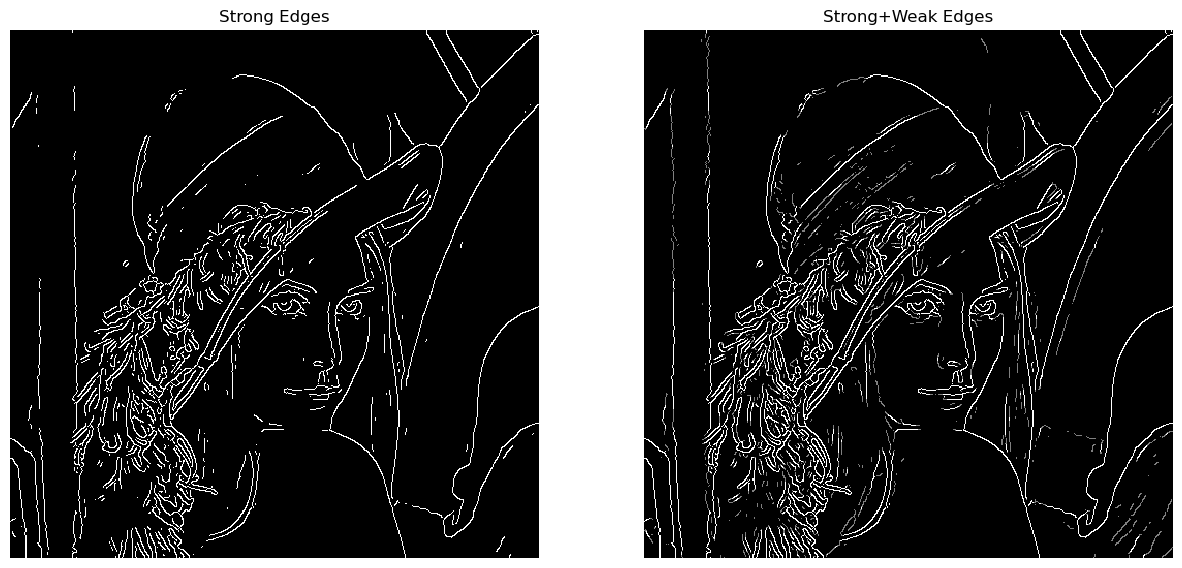

In [123]:
low_threshold = 0.02
high_threshold = 0.03

strong_edges, weak_edges = double_thresholding(nms, high_threshold, low_threshold)
assert(np.sum(strong_edges & weak_edges) == 0)

edges=strong_edges * 1.0 + weak_edges * 0.5

plt.subplot(1,2,1)
plt.imshow(strong_edges)
plt.title('Strong Edges')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(edges)
plt.title('Strong+Weak Edges')
plt.axis('off')

plt.show()

### 1.5 边缘连接 Edge tracking

### 什么是边缘连接？
边缘连接是Canny边缘检测的最后一步，也称为滞后阈值连接（Hysteresis Thresholding）。它通过将弱边缘与强边缘连接，形成连续的边缘轮廓。

### 为什么需要边缘连接？
经过双阈值检测后，我们得到：
- **强边缘**：确信的真实边缘
- **弱边缘**：可能是真实边缘，也可能是噪声

边缘连接的目标：
- **保留真实边缘**：将属于真实边缘的弱边缘保留
- **去除噪声**：抑制孤立的弱边缘
- **保持连续性**：形成完整的边缘轮廓

### 连接策略

#### 1. 八邻域连接
检查弱边缘像素周围8个方向是否有强边缘：

NW N NE

W P E

SW S SE

#### 2. 递归连接
从强边缘出发，递归地连接相邻的弱边缘。

#### 3. 迭代连接
使用形态学操作，迭代地扩张边缘区域。

### 数学表示

设 $S$ 为强边缘集合，$W$ 为弱边缘集合。

连接规则：
$$\text{最终边缘} = S \cup \{w \in W | \exists s \in S, \text{dist}(w,s) \leq 1\}$$

其中 $\text{dist}(w,s)$ 表示8邻域距离。


强边缘被解释为“确定性边缘”，可以直接包含在最终的边缘图像中。弱边缘当且仅当与强边缘相连时才会被包含进来。其逻辑是：噪声和其他微小变化不太可能产生强边缘（通过适当调整阈值水平）。因此，强边缘（几乎）只能来自原始图像中的真实边缘。

弱边缘可能来源于真实边缘，也可能来源于噪声或颜色变化。后者可能在整幅图像中独立分布，因此只有少量会与强边缘相邻。而由真实边缘产生的弱边缘，则更有可能直接与强边缘相连。

在中实现 link_edges 函数。

如果在差异图像中看到白色斑点，则应检查你的实现。

In [ ]:
from collections import deque

def get_neighbors(y, x, H, W):
    """ Return indices of valid neighbors of (y, x).

    Return indices of all the valid neighbors of (y, x) in an array of
    shape (H, W). An index (i, j) of a valid neighbor should satisfy
    the following:
        1. i >= 0 and i < H
        2. j >= 0 and j < W
        3. (i, j) != (y, x)

    Args:
        y, x: location of the pixel.
        H, W: size of the image.
    Returns:
        neighbors: list of indices of neighboring pixels [(i, j)].
    """
    neighbors = []

    for i in (y-1, y, y+1):
        for j in (x-1, x, x+1):
            if i >= 0 and i < H and j >= 0 and j < W:
                if (i == y and j == x):
                    continue
                neighbors.append((i, j))

    return neighbors

def link_edges(strong_edges, weak_edges):
    """ Find weak edges connected to strong edges and link them.

    Iterate over each pixel in strong_edges and perform breadth first
    search across the connected pixels in weak_edges to link them.
    Here we consider a pixel (a, b) is connected to a pixel (c, d)
    if (a, b) is one of the eight neighboring pixels of (c, d).

    Args:
        strong_edges: binary image of shape (H, W).
        weak_edges: binary image of shape (H, W).
    
    Returns:
        edges: numpy boolean array of shape(H, W).
    """

    H, W = strong_edges.shape
    indices = np.stack(np.nonzero(strong_edges)).T
    edges = np.zeros((H, W), dtype=np.bool)

    # Make new instances of arguments to leave the original
    # references intact
    weak_edges = np.copy(weak_edges)
    edges = np.copy(strong_edges)
    ### YOUR CODE HERE

    ### END YOUR CODE

    return edges

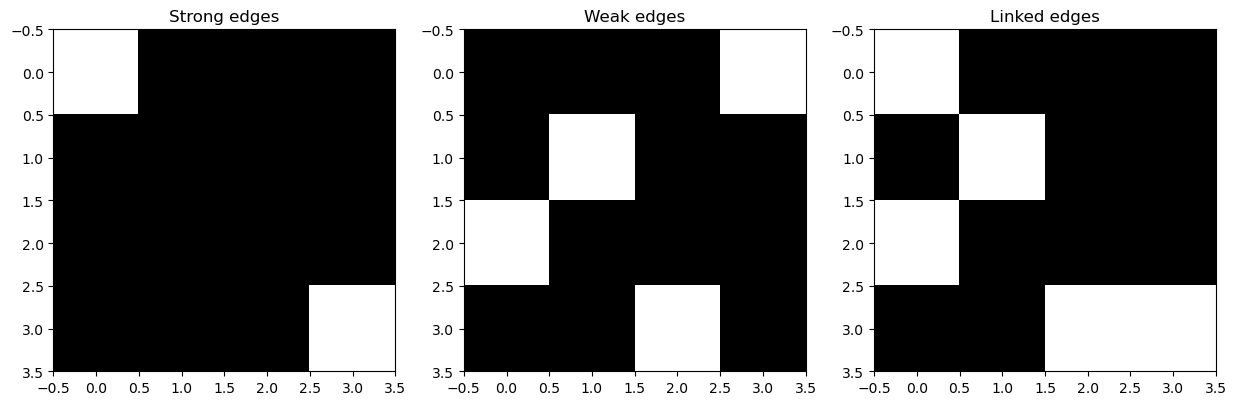

In [125]:
test_strong = np.array(
    [[1, 0, 0, 0],
     [0, 0, 0, 0],
     [0, 0, 0, 0],
     [0, 0, 0, 1]],
    dtype=np.bool
)

test_weak = np.array(
    [[0, 0, 0, 1],
     [0, 1, 0, 0],
     [1, 0, 0, 0],
     [0, 0, 1, 0]],
    dtype=np.bool
)

test_linked = link_edges(test_strong, test_weak)

plt.subplot(1, 3, 1)
plt.imshow(test_strong)
plt.title('Strong edges')

plt.subplot(1, 3, 2)
plt.imshow(test_weak)
plt.title('Weak edges')

plt.subplot(1, 3, 3)
plt.imshow(test_linked)
plt.title('Linked edges')
plt.show()

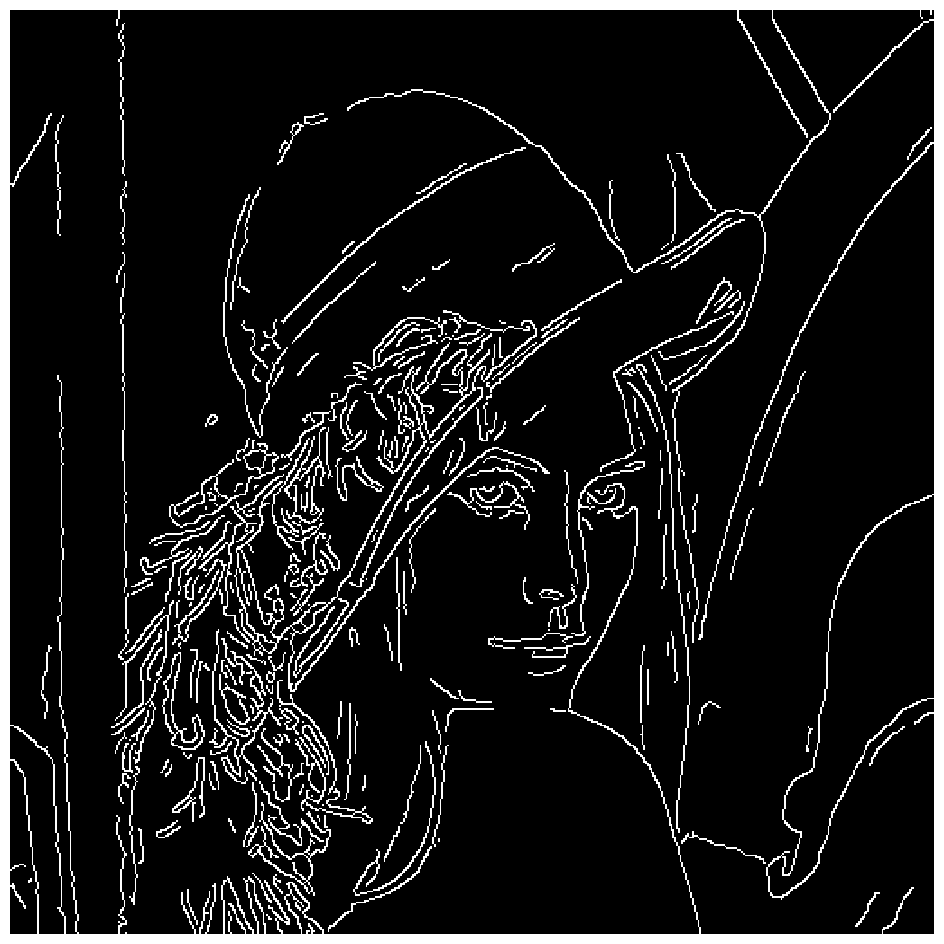

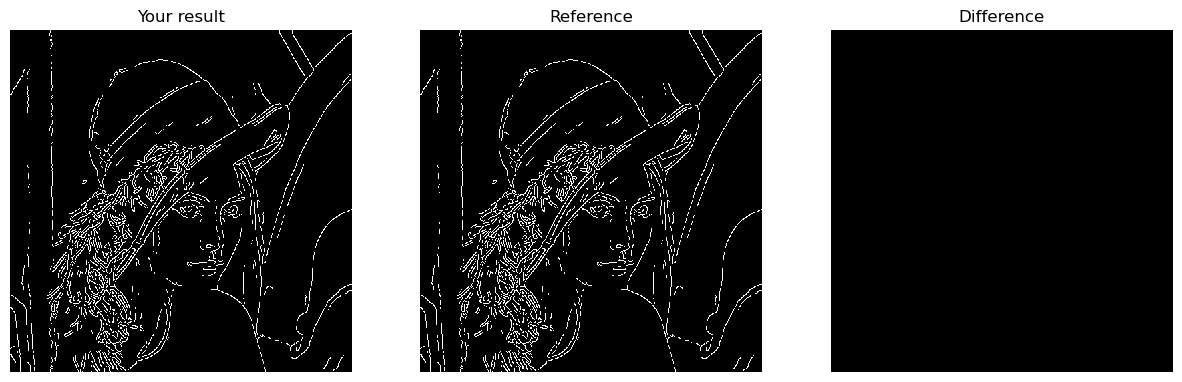

In [126]:
edges = link_edges(strong_edges, weak_edges)

plt.imshow(edges)
plt.axis('off')
plt.show()


plt.subplot(1, 3, 1)
plt.imshow(edges)
plt.axis('off')
plt.title('Your result')

plt.subplot(1, 3, 2)
reference = np.load('references/lena_edge_tracking.npy')
plt.imshow(reference)
plt.axis('off')
plt.title('Reference')

plt.subplot(1, 3, 3)
plt.imshow(edges ^ reference)
plt.title('Difference')
plt.axis('off')
plt.show()

### 1.6 Canny edge detector
融合几个步骤实现Canny edge detector

如果在差异图像中看到白色斑点，则应检查你的实现。

In [ ]:
def canny(img, kernel_size=5, sigma=1.4, high=20, low=15):
    """ Implement canny edge detector by calling functions above.

    Args:
        img: binary image of shape (H, W).
        kernel_size: int of size for kernel matrix.
        sigma: float for calculating kernel.
        high: high threshold for strong edges.
        low: low threashold for weak edges.
    Returns:
        edge: numpy array of shape(H, W).
    """
    ### YOUR CODE HERE

    ### END YOUR CODE

    return edge

(512, 512)


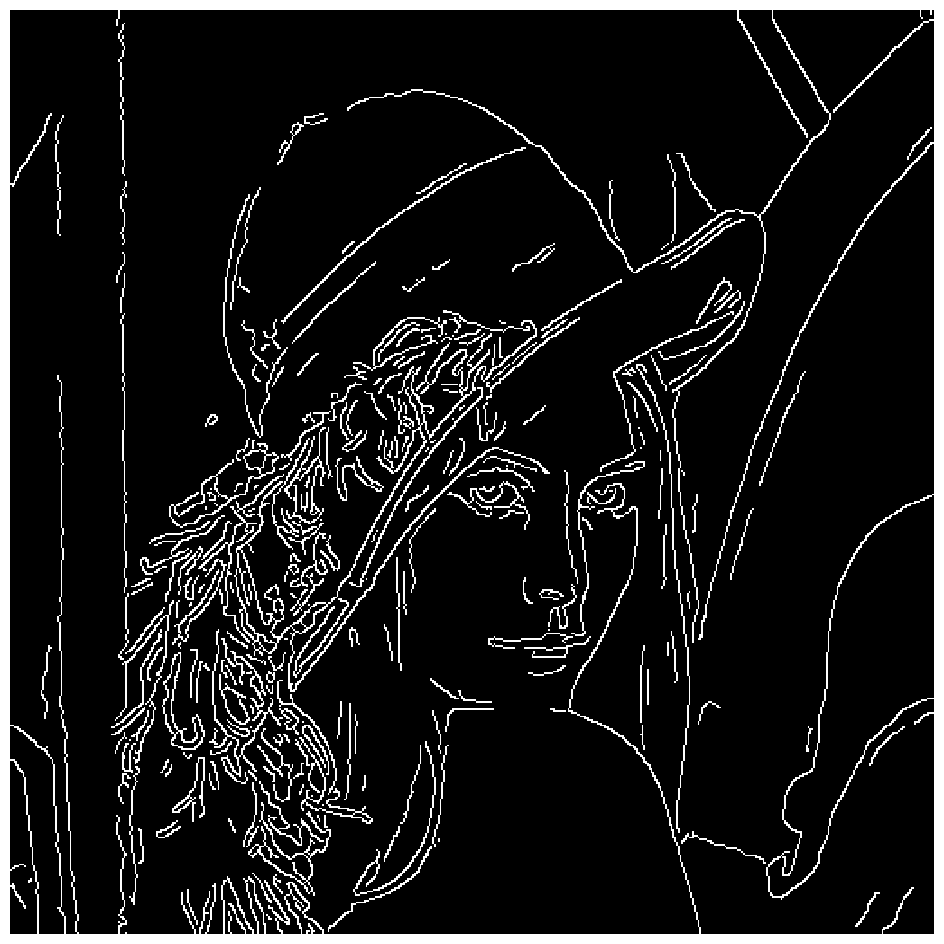

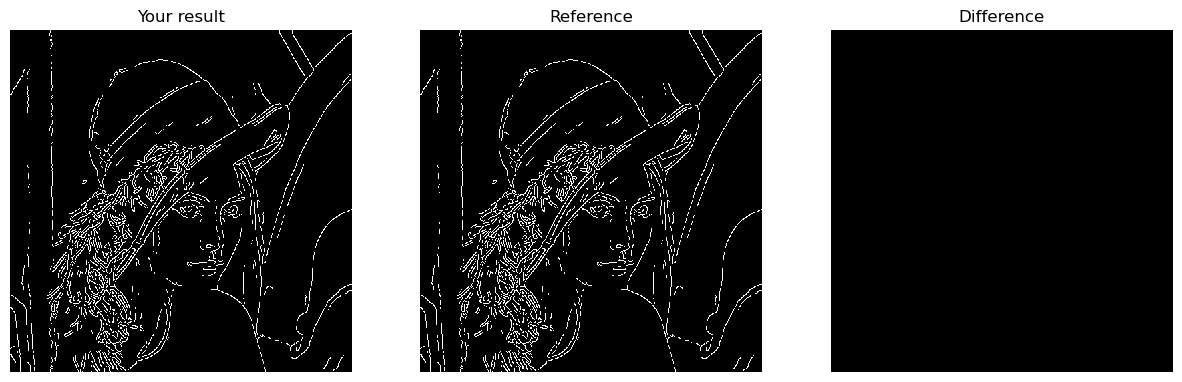

In [ ]:
# Load image
img = io.imread('lena.png', as_gray=True)


# Run Canny edge detector
edges = canny(img, kernel_size=5, sigma=1.4, high=0.03, low=0.02)

plt.imshow(edges)
plt.axis('off')
plt.show()

plt.subplot(1, 3, 1)
plt.imshow(edges)
plt.axis('off')
plt.title('Your result')

plt.subplot(1, 3, 2)
reference = np.load('references/lena_canny.npy')
plt.imshow(reference)
plt.axis('off')
plt.title('Reference')

plt.subplot(1, 3, 3)
plt.imshow(edges ^ reference)
plt.title('Difference')
plt.axis('off')
plt.show()